In [ ]:
import pandas as pd
df=pd.read_csv("youtube.csv")
df.head()

,index,video_id,trending_date,title,channel_title,category_id,publish_date,time_frame,published_day_of_week,publish_country,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,13/11/2017,17:00 to 17:59,Monday,US,SHANtell martin,748374,57527,2966,15954,False,False,False
1,1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,13/11/2017,7:00 to 7:59,Monday,US,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,False,False,False
2,2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,12/11/2017,19:00 to 19:59,Sunday,US,"racist superman|""rudy""""|""""mancuso""""|""""king""""|""...",3191434,146033,5339,8181,False,False,False
3,3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,13/11/2017,11:00 to 11:59,Monday,US,"rhett and link|""gmm""""|""""good mythical morning""...",343168,10172,666,2146,False,False,False
4,4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,12/11/2017,18:00 to 18:59,Sunday,US,"ryan|""higa""""|""""higatv""""|""""nigahiga""""|""""i dare ...",2095731,132235,1989,17518,False,False,False


In [ ]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%y.%d.%m")
df["publish_date"] = pd.to_datetime(df["publish_date"], format="%d/%m/%Y")

In [37]:
df["trending_duration"] = (df["trending_date"] - df["publish_date"]).dt.days

In [34]:
df["publish_hour"] = df["publish_date"].dt.hour

In [ ]:
df["engagement_rate"] = (df["likes"] + df["comment_count"]) / df["views"]

In [ ]:
pip install textblob

In [38]:
from textblob import TextBlob

df["title_sentiment_score"] = df["title"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

def label_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["title_sentiment"] = df["title_sentiment_score"].apply(label_sentiment)

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

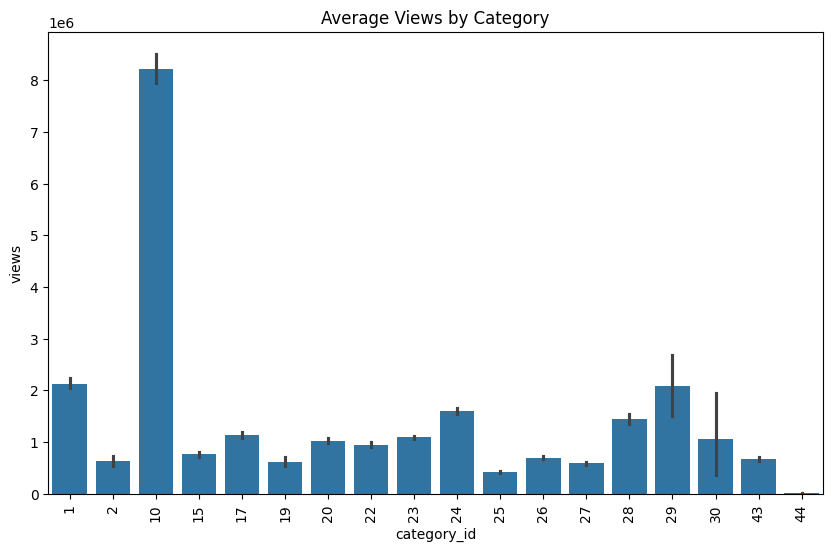

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
sns.barplot(
    x=df["category_id"],
    y=df["views"],
    estimator=np.mean
)
plt.title("Average Views by Category")
plt.xticks(rotation=90)
plt.show()

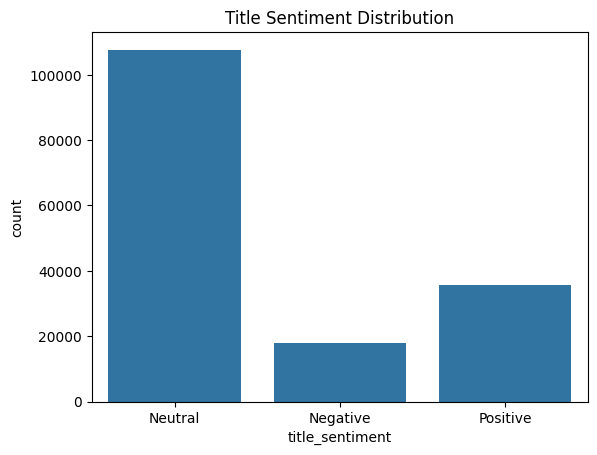

In [32]:
sns.countplot(data=df, x="title_sentiment")
plt.title("Title Sentiment Distribution")
plt.show()

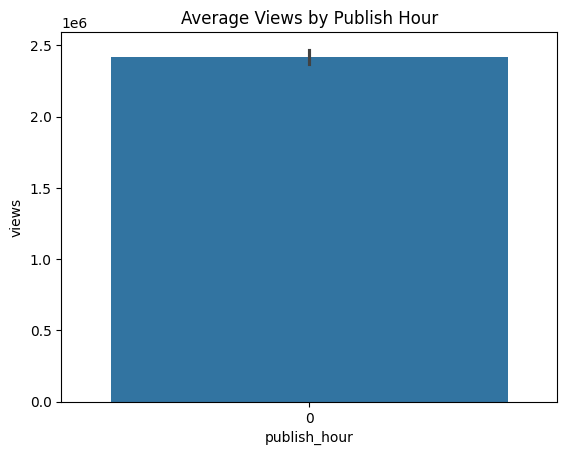

In [35]:
sns.barplot(
    x=df["publish_hour"],
    y=df["views"],
    estimator=np.mean
)
plt.title("Average Views by Publish Hour")
plt.show()

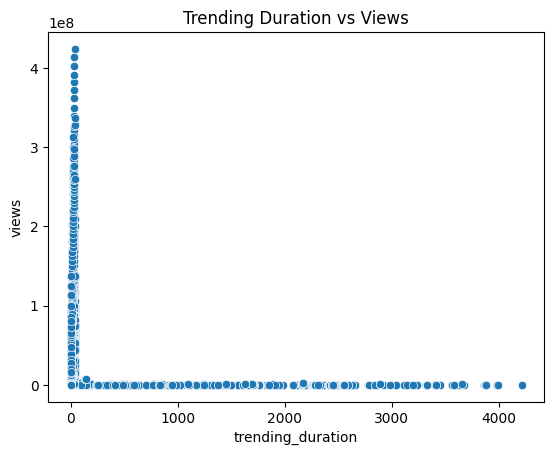

In [39]:
sns.scatterplot(
    x=df["trending_duration"],
    y=df["views"]
)
plt.title("Trending Duration vs Views")
plt.show()

In [40]:
df.to_csv("cleaned_youtube.csv", index=False)

In [42]:
df.to_csv("raw_youtube.csv", index=False)